# Skill Prediction Model
Given a user's skills and a target job role, this model predicts:
- **Relevant Skills** – skills the user has that match the role
- **Irrelevant Skills** – skills the user has that are NOT needed for the role
- **Skills to Learn** – skills required for the role that the user is missing

In [8]:
import json
import re
import pandas as pd
import numpy as np
import subprocess
import sys

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter

## 1. Load & Explore Data

In [9]:
with open('job_dataset.json', 'r', encoding='utf-8') as f:
    job_data = json.load(f)

df = pd.DataFrame(job_data)
print(f"Total records: {len(df)}")
print(f"Unique roles: {df['Title'].nunique()}")
print("\nAvailable roles:")
for role in sorted(df['Title'].dropna().unique()):
    print(f"  - {role}")

Total records: 1068
Unique roles: 218

Available roles:
  - .NET Developer
  - AI Engineer - Experienced
  - AI Engineer - Fresher
  - AI Prompt Engineer
  - AR/VR Developer
  - Android App Developer Trainee
  - Android Architect
  - Android Developer
  - Android Developer Intern
  - Android Developer Trainee
  - Android Development Intern
  - Android Solutions Architect
  - Android Solutions Engineer
  - Android Tech Lead
  - Associate Android Developer
  - Associate Cloud Architect
  - Associate Cybersecurity Analyst
  - Associate Network Engineer
  - Associate System Engineer
  - Associate UX Designer
  - Associate iOS Engineer
  - BI Analyst - Experienced
  - BI Analyst - Fresher
  - Backend Developer - Entry Level
  - Backend Developer - Experienced
  - Big Data Specialist
  - Blockchain Developer
  - Business Analyst
  - Cloud Architect
  - Cloud Automation Engineer
  - Cloud Cost Optimization Architect
  - Cloud DevSecOps Architect
  - Cloud Engineer
  - Cloud Engineer - Experie

## 2. Skill Normalization & Role Aggregation

In [10]:
QUALIFIERS = r'\b(basics|fundamentals|advanced|expert|intro|introductory|basic|intermediate)\b'

def normalize_skill(skill: str) -> str:
    skill = skill.lower().strip()
    skill = re.sub(QUALIFIERS, '', skill)
    skill = re.sub(r'\s+', ' ', skill).strip()
    return skill

def get_role_skill_profile(role_title: str, top_n: int = 20) -> dict:
    """Returns top N skills with frequency weights for a given role."""
    entries = df[df['Title'] == role_title]
    skill_counter = Counter()
    for _, row in entries.iterrows():
        for skill in row.get('Skills', []):
            normalized = normalize_skill(skill)
            if normalized:
                skill_counter[normalized] += 1
    total = sum(skill_counter.values())
    top_skills = skill_counter.most_common(top_n)
    return {
        'skills': [s for s, _ in top_skills],
        'weights': {s: c / total for s, c in top_skills}
    }

# Build role profiles for all roles
unique_roles = sorted(df['Title'].dropna().unique())
role_profiles = {role: get_role_skill_profile(role) for role in unique_roles}
print(f"Built profiles for {len(role_profiles)} roles.")

Built profiles for 218 roles.


## 3. TF-IDF Vectorizer for Fuzzy Skill Matching

In [11]:
# Collect all unique normalized skills across all roles
all_skills = set()
for profile in role_profiles.values():
    all_skills.update(profile['skills'])
all_skills = sorted(all_skills)

# Fit TF-IDF on skill corpus for fuzzy matching
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))
skill_vectors = vectorizer.fit_transform(all_skills)

def fuzzy_match_skill(user_skill: str, threshold: float = 0.35) -> str | None:
    """Finds the closest skill in the dataset using character n-gram similarity."""
    user_vec = vectorizer.transform([user_skill])
    sims = cosine_similarity(user_vec, skill_vectors).flatten()
    best_idx = sims.argmax()
    if sims[best_idx] >= threshold:
        return all_skills[best_idx]
    return None

print(f"Vocabulary size: {len(all_skills)} unique skills")
# Quick test
print(f"Fuzzy match 'pytorch' -> {fuzzy_match_skill('pytorch')}")
print(f"Fuzzy match 'react js' -> {fuzzy_match_skill('react js')}")

Vocabulary size: 797 unique skills
Fuzzy match 'pytorch' -> pytorch
Fuzzy match 'react js' -> react


## 4. Core Prediction Function

In [12]:
def predict_skills(user_skills_input: str, target_role: str, top_n: int = 20) -> dict:
    """
    Predicts skill relevance for a user targeting a specific role.

    Parameters:
        user_skills_input : comma-separated string of user's skills
        target_role       : job role title from the dataset
        top_n             : number of top role skills to consider

    Returns:
        dict with keys: role, match_score, relevant, irrelevant, skills_to_learn
    """
    if target_role not in role_profiles:
        available = ', '.join(unique_roles)
        raise ValueError(f"Role '{target_role}' not found. Available roles:\n{available}")

    # Normalize user skills
    raw_user_skills = [s.strip() for s in user_skills_input.split(',') if s.strip()]
    user_skills_normalized = [normalize_skill(s) for s in raw_user_skills]

    # Fuzzy-map user skills to known dataset skills
    user_skills_mapped = {}
    for orig, norm in zip(raw_user_skills, user_skills_normalized):
        matched = fuzzy_match_skill(norm)
        user_skills_mapped[orig] = matched  # None if no match found

    mapped_set = {v for v in user_skills_mapped.values() if v is not None}

    # Get role's required skills
    profile = get_role_skill_profile(target_role, top_n=top_n)
    required_skills = profile['skills']
    weights = profile['weights']

    # Classify user skills
    relevant = []
    irrelevant = []
    for orig, mapped in user_skills_mapped.items():
        if mapped and any(
            mapped in req or req in mapped or
            cosine_similarity(
                vectorizer.transform([mapped]),
                vectorizer.transform([req])
            )[0][0] > 0.5
            for req in required_skills
        ):
            relevant.append(orig)
        else:
            irrelevant.append(orig)

    # Skills to learn = required skills not covered by user
    skills_to_learn = []
    for req in required_skills:
        covered = any(
            req in m or m in req or
            cosine_similarity(
                vectorizer.transform([req]),
                vectorizer.transform([m])
            )[0][0] > 0.5
            for m in mapped_set if m
        )
        if not covered:
            skills_to_learn.append(req)

    # Weighted match score
    matched_weight = sum(weights.get(req, 0) for req in required_skills if req not in skills_to_learn)
    total_weight = sum(weights.values())
    score = round((matched_weight / total_weight) * 100, 1) if total_weight > 0 else 0

    return {
        'role': target_role,
        'match_score': score,
        'relevant_skills': relevant,
        'irrelevant_skills': irrelevant,
        'skills_to_learn': skills_to_learn
    }

print("predict_skills() function ready.")

predict_skills() function ready.


## 5. Role Discovery – Find Best Matching Roles

In [13]:
def discover_best_roles(user_skills_input: str, top_k: int = 5) -> pd.DataFrame:
    """Ranks all roles by match score for the given user skills."""
    results = []
    for role in unique_roles:
        try:
            pred = predict_skills(user_skills_input, role)
            results.append({
                'Role': pred['role'],
                'Match Score (%)': pred['match_score'],
                'Relevant Skills': len(pred['relevant_skills']),
                'Skills to Learn': len(pred['skills_to_learn'])
            })
        except Exception:
            continue
    result_df = pd.DataFrame(results).sort_values('Match Score (%)', ascending=False).reset_index(drop=True)
    return result_df.head(top_k)

print("discover_best_roles() function ready.")

discover_best_roles() function ready.


## 6. Pretty Print Helper

In [14]:
def display_prediction(result: dict):
    print("=" * 55)
    print(f"  Role         : {result['role']}")
    print(f"  Match Score  : {result['match_score']}%")
    print("=" * 55)

    print(f"\n✅ RELEVANT SKILLS ({len(result['relevant_skills'])}) – You already have these:")
    for s in result['relevant_skills']:
        print(f"   • {s}")

    print(f"\n❌ IRRELEVANT SKILLS ({len(result['irrelevant_skills'])}) – Not needed for this role:")
    for s in result['irrelevant_skills']:
        print(f"   • {s}")

    print(f"\n📚 SKILLS TO LEARN ({len(result['skills_to_learn'])}) – Required but you don't have them:")
    for s in result['skills_to_learn']:
        print(f"   • {s}")
    print()

## 7. Example Predictions

**Change `user_skills` and `target_role` to test with your own data.**

In [15]:
# --- USER INPUT ---
user_skills = "Python, TensorFlow, SQL, Pandas, NumPy, HTML, CSS"
target_role = "AI Engineer - Fresher"
# ------------------

result = predict_skills(user_skills, target_role)
display_prediction(result)

  Role         : AI Engineer - Fresher
  Match Score  : 32.7%

✅ RELEVANT SKILLS (5) – You already have these:
   • Python
   • TensorFlow
   • SQL
   • Pandas
   • NumPy

❌ IRRELEVANT SKILLS (2) – Not needed for this role:
   • HTML
   • CSS

📚 SKILLS TO LEARN (13) – Required but you don't have them:
   • java
   • c++
   • regression
   • classification
   • clustering
   • pytorch
   • keras
   • scikit-learn
   • neural networks
   • opencv
   • nltk
   • mongodb
   • supervised/unsupervised learning



In [16]:
# Another example – Android Developer
user_skills2 = "Java, Kotlin, Android Studio, Git, REST API, Firebase, Docker"
target_role2 = "Android Developer"

result2 = predict_skills(user_skills2, target_role2)
display_prediction(result2)

  Role         : Android Developer
  Match Score  : 60.0%

✅ RELEVANT SKILLS (6) – You already have these:
   • Java
   • Kotlin
   • Android Studio
   • Git
   • REST API
   • Firebase

❌ IRRELEVANT SKILLS (1) – Not needed for this role:
   • Docker

📚 SKILLS TO LEARN (4) – Required but you don't have them:
   • jetpack
   • mvvm
   • room
   • unit testing



In [17]:
# Discover best-fit roles for a user
user_skills3 = "Python, Spark, Hadoop, SQL, Kafka, AWS"
print(f"Top role matches for: '{user_skills3}'\n")
discover_best_roles(user_skills3, top_k=5)

Top role matches for: 'Python, Spark, Hadoop, SQL, Kafka, AWS'



,Role,Match Score (%),Relevant Skills,Skills to Learn
0,Machine Learning Engineer - Experienced,55.6,5,4
1,Data Engineer,52.6,6,10
2,Lead ML/AI Engineer,50.0,5,5
3,Principal Machine Learning Engineer,50.0,5,5
4,Lead Machine Learning Engineer,50.0,5,5


## 8. Interactive Prediction (run this cell to enter your own data)

In [18]:
print("Available roles:")
for i, r in enumerate(unique_roles, 1):
    print(f"  {i:3}. {r}")

print()
user_input_skills = input("Enter your skills (comma-separated): ")
user_input_role   = input("Enter target role (exact name from list above): ")

try:
    res = predict_skills(user_input_skills, user_input_role)
    display_prediction(res)
except ValueError as e:
    print(f"\nError: {e}")

Available roles:
    1. .NET Developer
    2. AI Engineer - Experienced
    3. AI Engineer - Fresher
    4. AI Prompt Engineer
    5. AR/VR Developer
    6. Android App Developer Trainee
    7. Android Architect
    8. Android Developer
    9. Android Developer Intern
   10. Android Developer Trainee
   11. Android Development Intern
   12. Android Solutions Architect
   13. Android Solutions Engineer
   14. Android Tech Lead
   15. Associate Android Developer
   16. Associate Cloud Architect
   17. Associate Cybersecurity Analyst
   18. Associate Network Engineer
   19. Associate System Engineer
   20. Associate UX Designer
   21. Associate iOS Engineer
   22. BI Analyst - Experienced
   23. BI Analyst - Fresher
   24. Backend Developer - Entry Level
   25. Backend Developer - Experienced
   26. Big Data Specialist
   27. Blockchain Developer
   28. Business Analyst
   29. Cloud Architect
   30. Cloud Automation Engineer
   31. Cloud Cost Optimization Architect
   32. Cloud DevSecOps 

## 9. Visualize Skill Gap

Matplotlib is building the font cache; this may take a moment.


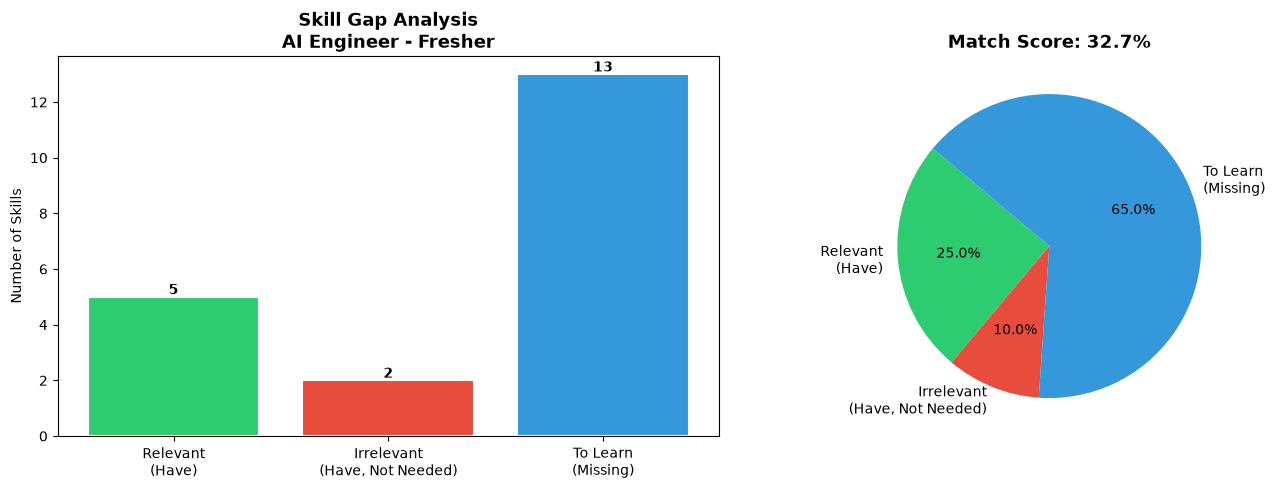

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_skill_gap(result: dict):
    categories = ['Relevant\n(Have)', 'Irrelevant\n(Have, Not Needed)', 'To Learn\n(Missing)']
    counts = [
        len(result['relevant_skills']),
        len(result['irrelevant_skills']),
        len(result['skills_to_learn'])
    ]
    colors = ['#2ecc71', '#e74c3c', '#3498db']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    axes[0].bar(categories, counts, color=colors, edgecolor='white', linewidth=1.5)
    axes[0].set_title(f"Skill Gap Analysis\n{result['role']}", fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Number of Skills')
    for i, v in enumerate(counts):
        axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

    # Pie chart
    non_zero = [(c, cat, col) for c, cat, col in zip(counts, categories, colors) if c > 0]
    if non_zero:
        vals, cats, cols = zip(*non_zero)
        axes[1].pie(vals, labels=cats, colors=cols, autopct='%1.1f%%',
                    startangle=140, textprops={'fontsize': 10})
        axes[1].set_title(f"Match Score: {result['match_score']}%", fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Plot for the first example
plot_skill_gap(result)